---
## ✏️ Step 7: 도전 과제

### 🟢 기초
1. 7-Segment 실험에서 노이즈를 `0.0`, `0.1`, `0.2`, `0.3`으로 변화시켜
   각 노이즈 수준별 최적 기법이 무엇인지 실험하세요.
2. `CosineAnnealingWarmRestarts`의 `T_0` 값(10, 20, 40, 80)을 바꿔
   재시작 주기가 수렴에 미치는 영향을 그래프로 확인하세요.

### 🟡 중급
3. MNIST에서 `label_smoothing` 값을 `0.0`, `0.05`, `0.1`, `0.2`로 변화시키고
   경계 케이스(3↔8, 4↔9) 오분류율이 어떻게 달라지는지 Confusion Matrix로 비교하세요.
4. SWA의 시작 에폭(`swa_start`)을 5, 10, 12로 변화시켜 최적값을 찾으세요.

### 🔴 심화
5. **Lookahead Optimizer**를 직접 구현하거나 `torchcontrib`을 사용하여
   AdamW와 비교해보세요.
6. **SAM (Sharpness-Aware Minimization)** 옵티마이저의 아이디어를 조사하고,
   간단한 버전을 직접 구현하여 MNIST에 적용해보세요.
7. 7-Segment MLP를 5층 깊은 네트워크(7→256→128→64→32→10)로 바꾸면
   Vanishing Gradient가 발생하는지 확인하고, BatchNorm을 추가하면 어떻게 되나요?

In [1]:
# ✏️ 도전 과제 코드 공간

# ── 예시: 노이즈 수준별 최적 기법 탐색 ──────────────────────────────────
# noise_levels = [0.0, 0.05, 0.10, 0.20, 0.30]
# best_methods = {}
# for noise in noise_levels:
#     h_base,  _ = train_seg(lambda p: optim.Adam(p, lr=0.001), epochs=150, noise=noise)
#     h_cosine,_ = train_seg(
#         lambda p: optim.AdamW(p, lr=0.001, weight_decay=1e-4),
#         sched_fn=lambda opt: optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=40),
#         epochs=150, noise=noise, grad_clip=1.0)
#     diff = h_cosine['test_acc'][-1] - h_base['test_acc'][-1]
#     print(f'noise={noise:.2f}: baseline={h_base["test_acc"][-1]*100:.1f}%,'
#           f' cosine+clip={h_cosine["test_acc"][-1]*100:.1f}%, 개선={diff*100:.2f}%p')

print('도전 과제를 직접 구현해보세요! 🚀')

# 환경설정 및 공통 유틸리티
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.swa_utils import AveragedModel, SWALR
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# ─── 공통 색상 팔레트 ─────────────────────────────────────────────────────
COLORS = {
    'baseline':  '#7fa8c4',
    'momentum':  '#00c9a7',
    'adam':      '#00a8cc',
    'cosine':    '#a78bfa',
    'adamw':     '#fb7185',
    'swa':       '#ffb74d',
    'full':      '#69f0ae',
    'grad_clip': '#ff5252',
    'bg':        '#0d1b2a',
    'panel':     '#162236',
    'amber':     '#ffb74d',
}

def set_dark_style(ax):
    """다크 테마 matplotlib 스타일 설정"""
    ax.set_facecolor(COLORS['panel'])
    ax.tick_params(colors='#7fa8c4')
    ax.xaxis.label.set_color('#7fa8c4')
    ax.yaxis.label.set_color('#7fa8c4')
    ax.title.set_color('white')
    for sp in ax.spines.values():
        sp.set_edgecolor('#1e3a54')
    ax.grid(alpha=0.2, color='#1e3a54')

def plot_comparison(histories: dict, metric: str, title: str, ylabel: str, scale=100):
    """여러 실험 결과를 하나의 그래프에 비교"""
    fig, ax = plt.subplots(figsize=(11, 5))
    fig.patch.set_facecolor(COLORS['bg'])
    set_dark_style(ax)
    for name, h in histories.items():
        vals = [v * scale for v in h[metric]]
        ax.plot(vals, label=name, linewidth=2, color=COLORS.get(name.lower().split()[0], '#ffffff'))
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend(facecolor=COLORS['panel'], labelcolor='white', fontsize=9)
    plt.tight_layout()
    plt.show()

# 한글 폰트 설정(추가 입력)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print('✅ 유틸리티 로드 완료')

도전 과제를 직접 구현해보세요! 🚀
Device: cuda
✅ 유틸리티 로드 완료


=== 1. 7-Segment 노이즈 수준별 최적 기법 탐색 ===

🌊 Noise = 0.00 실험 중...
  1. Adam(Baseline)        : 100.0%
  2. AdamW + Clip          : 100.0%
  3. AdamW + Cosine + Clip :  90.0%
🏆 결과: 노이즈 0.00 최적 기법 ➡️ '1. Adam(Baseline)'

🌊 Noise = 0.05 실험 중...
  1. Adam(Baseline)        :  88.7%
  2. AdamW + Clip          :  84.7%
  3. AdamW + Cosine + Clip :  83.0%
🏆 결과: 노이즈 0.05 최적 기법 ➡️ '1. Adam(Baseline)'

🌊 Noise = 0.10 실험 중...
  1. Adam(Baseline)        :  73.2%
  2. AdamW + Clip          :  73.8%
  3. AdamW + Cosine + Clip :  70.2%
🏆 결과: 노이즈 0.10 최적 기법 ➡️ '2. AdamW + Clip'

🌊 Noise = 0.20 실험 중...
  1. Adam(Baseline)        :  53.5%
  2. AdamW + Clip          :  52.7%
  3. AdamW + Cosine + Clip :  49.2%
🏆 결과: 노이즈 0.20 최적 기법 ➡️ '1. Adam(Baseline)'

🌊 Noise = 0.30 실험 중...
  1. Adam(Baseline)        :  30.8%
  2. AdamW + Clip          :  33.0%
  3. AdamW + Cosine + Clip :  28.7%
🏆 결과: 노이즈 0.30 최적 기법 ➡️ '2. AdamW + Clip'

✨ [최종 결과] 노이즈 환경별 최적의 기법 요약 ✨
-------------------------------------------------------

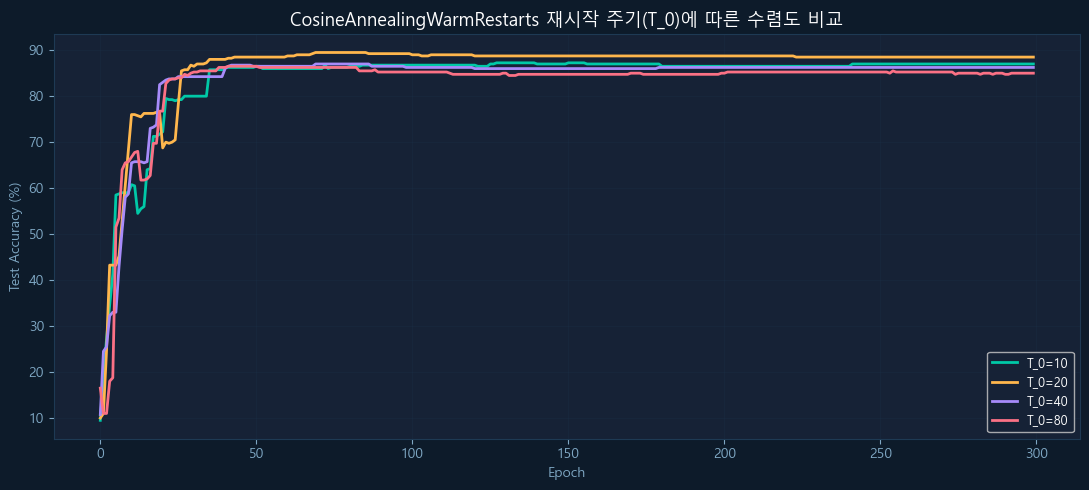


✨ 2. CosineAnnealingWarmRestarts 주기(T_0) 변경 실험 결과 요약(노이즈 0.05, 에폭 300) ✨
-------------------------------------------------------
 📍 T_0 = 10 주기 :  87.0%  
 📍 T_0 = 20 주기 :  88.5%  👑 (Best)
 📍 T_0 = 40 주기 :  86.2%  
 📍 T_0 = 80 주기 :  85.0%  
💡 결론: 노이즈 0.05 환경에서는 T_0 값이 [20]일 때 지역 최소값(Local Minima) 탈출 타이밍이 가장 적절했습니다!


In [18]:
# 기초
# 1. 7-Segment 실험에서 노이즈를 `0.0`, `0.1`, `0.2`, `0.3`으로 변화시켜
#    각 노이즈 수준별 최적 기법이 무엇인지 실험하세요.
# 2. `CosineAnnealingWarmRestarts`의 `T_0` 값(10, 20, 40, 80)을 바꿔
#    재시작 주기가 수렴에 미치는 영향을 그래프로 확인하세요.

# ─── 1. 노이즈 수준별 최적 기법 탐색 ──────────────────────────────
# 7-Segment 데이터 준비
SEGMENTS = {
    0:[1,1,1,1,1,1,0], 1:[0,1,1,0,0,0,0], 2:[1,1,0,1,1,0,1],
    3:[1,1,1,1,0,0,1], 4:[0,1,1,0,0,1,1], 5:[1,0,1,1,0,1,1],
    6:[1,0,1,1,1,1,1], 7:[1,1,1,0,0,0,0], 8:[1,1,1,1,1,1,1],
    9:[1,1,1,1,0,1,1],
}

def make_seg_data(noise_prob=0.05, samples=200):
    X, y = [], []
    for digit, pat in SEGMENTS.items():
        for _ in range(samples):
            noise = np.random.binomial(1, noise_prob, 7)
            X.append((np.array(pat) ^ noise).astype(np.float32))
            y.append(digit)
    X, y = np.array(X), np.array(y)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    return (torch.FloatTensor(Xtr).to(device), torch.LongTensor(ytr).to(device),
            torch.FloatTensor(Xte).to(device), torch.LongTensor(yte).to(device))


class SevenSegNet(nn.Module):
    def __init__(self, h1=64, h2=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(7, h1), nn.ReLU(),
            nn.Linear(h1, h2), nn.ReLU(),
            nn.Linear(h2, 10),
        )
    def forward(self, x): return self.net(x)


def train_seg(opt_fn, sched_fn=None, epochs=120, noise=0.05, grad_clip=None, label_smooth=0.0):
    """7-Segment 학습 실험 함수."""
    Xtr, ytr, Xte, yte = make_seg_data(noise_prob=noise)
    model = SevenSegNet(64, 32).to(device)
    optimizer = opt_fn(model.parameters())
    scheduler = sched_fn(optimizer) if sched_fn else None
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smooth)
    history = {'train_loss':[], 'train_acc':[], 'test_acc':[], 'lr':[]}

    for ep in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(Xtr)
        loss = criterion(out, ytr)
        loss.backward()
        if grad_clip:
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        if scheduler: scheduler.step()

        _, pred_tr = torch.max(out, 1)
        tr_acc = (pred_tr == ytr).float().mean().item()

        model.eval()
        with torch.no_grad():
            _, pred_te = torch.max(model(Xte), 1)
            te_acc = (pred_te == yte).float().mean().item()

        history['train_loss'].append(loss.item())
        history['train_acc'].append(tr_acc)
        history['test_acc'].append(te_acc)
        history['lr'].append(optimizer.param_groups[0]['lr'])

    return history, model

# 1. 7-Segment 노이즈 수준별 최적 기법 탐색
print("=== 1. 7-Segment 노이즈 수준별 최적 기법 탐색 ===")
noise_levels = [0.0, 0.05, 0.10, 0.20, 0.30]

# 각 기법마다 [옵티마이저, 스케줄러, 그래디언트 클리핑 수치]지정
methods = {
    '1. Adam(Baseline)': {
        'opt_fn': lambda p: optim.Adam(p, lr=0.001),
        'sched_fn': None,
        'grad_clip': 0.0
    },
    '2. AdamW + Clip': {
        'opt_fn': lambda p: optim.AdamW(p, lr=0.001, weight_decay=1e-4),
        'sched_fn': None,
        'grad_clip': 1.0
    },
    '3. AdamW + Cosine + Clip': {
        'opt_fn': lambda p: optim.AdamW(p, lr=0.001, weight_decay=1e-4),
        'sched_fn': lambda opt: optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=40),
        'grad_clip': 1.0
    }
}

best_methods = {} 

# 노이즈 수준을 높여가며 반복 실험
for noise in noise_levels:
    print(f"\n🌊 Noise = {noise:.2f} 실험 중...")
    
    best_name = ""
    best_acc = 0.0
    
    for name, config in methods.items():
        h, _ = train_seg(
            opt_fn=config['opt_fn'], 
            sched_fn=config['sched_fn'], 
            epochs=150, 
            noise=noise, 
            grad_clip=config['grad_clip']
        )
        
        final_acc = h['test_acc'][-1] * 100
        print(f"  {name:<25s}: {final_acc:>5.1f}%")
        
        # 최고 정확도 업데이트
        if final_acc > best_acc:
            best_acc = final_acc
            best_name = name
            
    # 최적 기법 출력
    best_methods[noise] = best_name
    print(f"🏆 결과: 노이즈 {noise:.2f} 최적 기법 ➡️ '{best_name}'")


# ── 1. 7-Segment 노이즈 수준별 최적 기법 최종 결과 요약 ──────────────────────────────────────────
print("\n" + "="*60)
print("✨ [최종 결과] 노이즈 환경별 최적의 기법 요약 ✨")
print("-" * 60)
for noise, best_name in best_methods.items():
    print(f" 📍 Noise {noise:.2f} 환경의 최적기법 : {best_name}")
print("=" * 60)


# ─── 2. CosineAnnealingWarmRestarts 주기(T_0) 변경 실험 ─────────────────
print("\n" + "="*55)
print("=== 2. CosineAnnealingWarmRestarts 주기(T_0) 비교 ===")
print("="*55)

t0_values = [10, 20, 40, 80]
histories_t0 = {}

# 💡 공통 그래프 함수가 색상을 찾을 수 있도록 COLORS 사전에 임시 색상 추가!
COLORS['t_0=10'] = '#00c9a7' # 민트
COLORS['t_0=20'] = '#ffb74d' # 오렌지
COLORS['t_0=40'] = '#a78bfa' # 보라
COLORS['t_0=80'] = '#fb7185' # 핑크살구

best_t0 = 0
best_acc = 0.0

for t0 in t0_values:
    # 모델 학습 (노이즈 0.05, 에폭 300 환경)
    h, _ = train_seg(
        lambda p: optim.AdamW(p, lr=0.005, weight_decay=1e-4),
        sched_fn=lambda opt: optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=t0, T_mult=1),
        epochs=300, noise=0.05
    )
    
    final_acc = h["test_acc"][-1] * 100
    histories_t0[f'T_0={t0}'] = h
    print(f'  T_0={t0:<2} | 최종 Test Acc: {final_acc:>5.1f}%')
    
    # 최고 정확도 업데이트
    if final_acc > best_acc:
        best_acc = final_acc
        best_t0 = t0

# 결과 시각화 
plot_comparison(histories_t0, 'test_acc', 'CosineAnnealingWarmRestarts 재시작 주기(T_0)에 따른 수렴도 비교', 'Test Accuracy (%)', scale=100)

# 최종 결과 요약 출
print('\n' + '='*55)
print('✨ 2. CosineAnnealingWarmRestarts 주기(T_0) 변경 실험 결과 요약(노이즈 0.05, 에폭 300) ✨')
print('-'*55)
for t0 in t0_values:
    acc = histories_t0[f'T_0={t0}']['test_acc'][-1] * 100
    crown = "👑 (Best)" if t0 == best_t0 else ""
    print(f" 📍 T_0 = {t0:<2} 주기 : {acc:>5.1f}%  {crown}")
print('='*55)
print(f"💡 결론: 노이즈 0.05 환경에서는 T_0 값이 [{best_t0}]일 때 지역 최소값(Local Minima) 탈출 타이밍이 가장 적절했습니다!")




=== 3. Label Smoothing 값에 따른 혼동 행렬 비율 변화 ===

🧪 Label Smoothing = 0.0 모델 훈련 시작...
  ✅ [ 15 / 15 ] 학습 완료! 채점 중...           
  >>> [결과] 3↔8, 4↔9 오답 횟수: 총 11회
--- Label Smoothing = 0.0 ---
 [3을 8로 오해]:  1번 | [8을 3으로 오해]:  2번
 [4를 9로 오해]:  2번 | [9를 4로 오해]:  6번


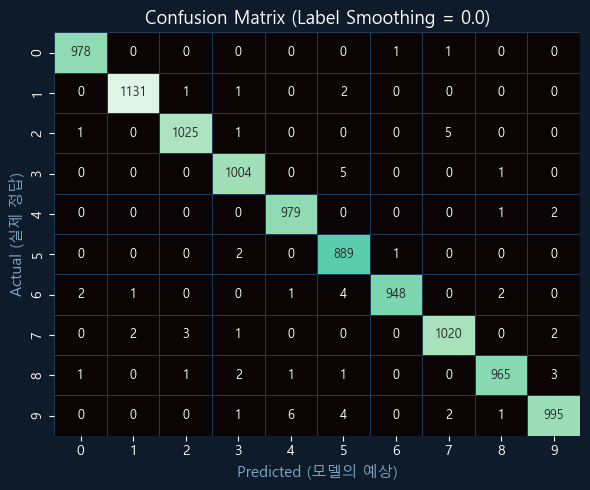


🧪 Label Smoothing = 0.05 모델 훈련 시작...
  ✅ [ 15 / 15 ] 학습 완료! 채점 중...           
  >>> [결과] 3↔8, 4↔9 오답 횟수: 총 10회
--- Label Smoothing = 0.05 ---
 [3을 8로 오해]:  1번 | [8을 3으로 오해]:  1번
 [4를 9로 오해]:  1번 | [9를 4로 오해]:  7번


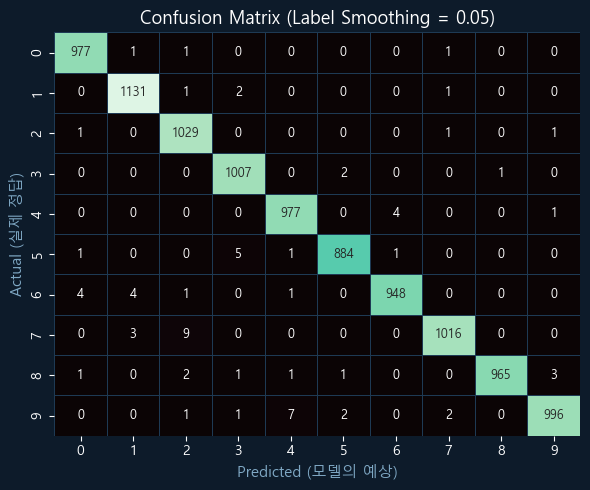


🧪 Label Smoothing = 0.1 모델 훈련 시작...
  ✅ [ 15 / 15 ] 학습 완료! 채점 중...           
  >>> [결과] 3↔8, 4↔9 오답 횟수: 총 9회
--- Label Smoothing = 0.1 ---
 [3을 8로 오해]:  1번 | [8을 3으로 오해]:  1번
 [4를 9로 오해]:  3번 | [9를 4로 오해]:  4번


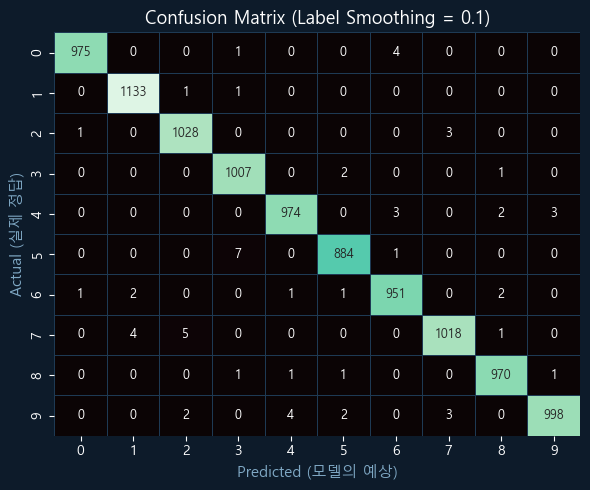


🧪 Label Smoothing = 0.2 모델 훈련 시작...
  ✅ [ 15 / 15 ] 학습 완료! 채점 중...           
  >>> [결과] 3↔8, 4↔9 오답 횟수: 총 16회
--- Label Smoothing = 0.2 ---
 [3을 8로 오해]:  1번 | [8을 3으로 오해]:  0번
 [4를 9로 오해]:  8번 | [9를 4로 오해]:  7번


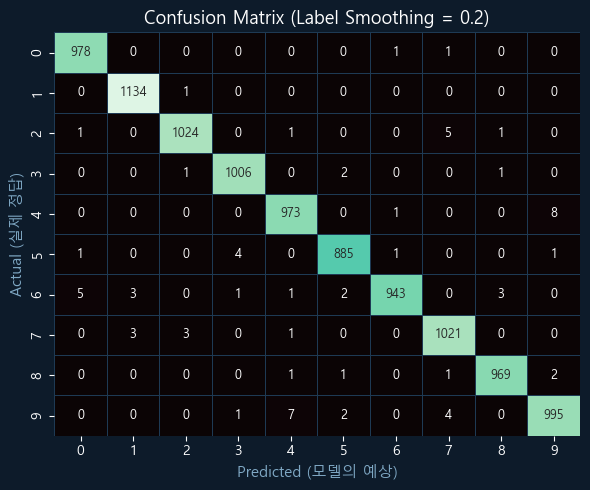



=== 4. SWA 시작 에폭 최적값 찾기 ===

🧪 [SWA_start = 5] 모델 훈련 시작...
  [SWA start at 5] Ep  1/15  Train:93.35%  Test:98.36%
  [SWA start at 5] Ep  2/15  Train:97.04%  Test:98.83%
  [SWA start at 5] Ep  3/15  Train:97.61%  Test:98.80%
  [SWA start at 5] Ep  4/15  Train:98.04%  Test:98.89%
  [SWA start at 5] Ep  5/15  Train:98.30%  Test:98.97%
  [SWA start at 5] Ep  6/15  Train:98.41%  Test:99.17%
  [SWA start at 5] Ep  7/15  Train:98.32%  Test:99.31%
  [SWA start at 5] Ep  8/15  Train:98.34%  Test:99.15%
  [SWA start at 5] Ep  9/15  Train:98.23%  Test:99.12%
  [SWA start at 5] Ep 10/15  Train:98.30%  Test:99.15%
  [SWA start at 5] Ep 11/15  Train:98.30%  Test:99.02%
  [SWA start at 5] Ep 12/15  Train:98.35%  Test:98.95%
  [SWA start at 5] Ep 13/15  Train:98.37%  Test:99.16%
  [SWA start at 5] Ep 14/15  Train:98.59%  Test:99.23%
  [SWA start at 5] Ep 15/15  Train:98.60%  Test:99.16%
  >>> SWA 최종 Test Acc: 99.250%
  >>> SWA start=5 최종 SWA 앙상블 성능: 99.25%

🧪 [SWA_start = 10] 모델 훈련 시작...
  [SWA star

In [21]:
# 중급
# 3. MNIST에서 `label_smoothing` 값을 `0.0`, `0.05`, `0.1`, `0.2`로 변화시키고
#    경계 케이스(3↔8, 4↔9) 오분류율이 어떻게 달라지는지 Confusion Matrix로 비교하세요.
# 4. SWA의 시작 에폭(`swa_start`)을 5, 10, 12로 변화시켜 최적값을 찾으세요.

# ─── MNIST 데이터 & 모델 ──────────────────────────────────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
train_ds = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_ds  = datasets.MNIST('./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=0)

# MNIST 모델 정의
class MnistCNN(nn.Module):
    def __init__(self, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64*7*7, 128), nn.ReLU(), nn.Dropout(dropout), nn.Linear(128,10)
        )
    def forward(self, x): return self.classifier(self.features(x))

# 공통 학습 및 평가 함수
def train_mnist_epoch(model, loader, criterion, optimizer, grad_clip=None):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        if grad_clip: nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct += (out.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss/total, correct/total


@torch.no_grad()
def eval_mnist(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        out = model(imgs)
        total_loss += criterion(out, labels).item() * imgs.size(0)
        correct += (out.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss/total, correct/total

# ─── 베이스라인 정의(Adam + CrossEntropy) ────────────────────────────

def run_mnist_exp(name, opt_fn, sched_fn=None, smooth=0.0, grad_clip=None, use_swa=False, swa_start=10, epochs=15):
    model = MnistCNN(dropout=0.5).to(device)
    optimizer = opt_fn(model.parameters())
    scheduler = sched_fn(optimizer) if sched_fn else None
    criterion = nn.CrossEntropyLoss(label_smoothing=smooth)
    h = {'train_loss':[], 'train_acc':[], 'test_loss':[], 'test_acc':[], 'lr':[]}

    swa_model = AveragedModel(model).to(device) if use_swa else None
    swa_sched  = SWALR(optimizer, swa_lr=0.005) if use_swa else None

    for ep in range(1, epochs+1):
        tl, ta = train_mnist_epoch(model, train_loader, criterion, optimizer, grad_clip)
        vl, va = eval_mnist(model, test_loader, criterion)

        if use_swa and ep >= swa_start:
            swa_model.update_parameters(model)
            swa_sched.step()
        elif scheduler:
            scheduler.step()

        h['train_loss'].append(tl); h['train_acc'].append(ta)
        h['test_loss'].append(vl);  h['test_acc'].append(va)
        h['lr'].append(optimizer.param_groups[0]['lr'])
        print(f'  [{name}] Ep {ep:>2}/{epochs}  Train:{ta*100:.2f}%  Test:{va*100:.2f}%')

    # SWA BN 업데이트
    if use_swa:
        torch.optim.swa_utils.update_bn(train_loader, swa_model, device=device)
        _, swa_acc = eval_mnist(swa_model, test_loader, criterion)
        print(f'  >>> SWA 최종 Test Acc: {swa_acc*100:.3f}%')
        h['swa_final_acc'] = swa_acc

    return h

# ─── 3. Label Smoothing 혼동 행렬 분석 ─────────────────────────────
print("\n" + "="*55)
print("\n=== 3. Label Smoothing 값에 따른 혼동 행렬 비율 변화 ===")
print("="*55)
smooth_vals = [0.0, 0.05, 0.1, 0.2]
ls_summary = {}
for sv in smooth_vals:
    print(f"\n🧪 Label Smoothing = {sv} 모델 훈련 시작...")
    model = MnistCNN(dropout=0.5).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss(label_smoothing=sv)
    
    # 15에폭 학습
    for ep in range(1, 16):
        train_mnist_epoch(model, train_loader, criterion, optimizer)
        print(f"  ⏳ 학습중... [ {ep:>2} / 15 ] 학습 완료!", end='\r')
        
    print(f"  ✅ [ 15 / 15 ] 학습 완료! 채점 중...           ")
        
    # 평가 모드에서 예측값-정답 추출
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, targets in test_loader:
            preds = model(inputs.to(device)).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(targets.numpy())
    # Confusion Matrix 계산
    cm = confusion_matrix(all_labels, all_preds)
    # [3↔8], [4↔9] 끼리 헷갈린 경우의 총합
    border_errors = cm[3][8] + cm[8][3] + cm[4][9] + cm[9][4]
    ls_summary[sv] = border_errors
    
    # 텍스트 출력
    print(f"  >>> [결과] 3↔8, 4↔9 오답 횟수: 총 {border_errors}회")
    print(f"--- Label Smoothing = {sv} ---")
    print(f" [3을 8로 오해]: {cm[3][8]:2d}번 | [8을 3으로 오해]: {cm[8][3]:2d}번")
    print(f" [4를 9로 오해]: {cm[4][9]:2d}번 | [9를 4로 오해]: {cm[9][4]:2d}번")
    
    # 컨퓨전 매트릭스 시각화 
    fig, ax = plt.subplots(figsize=(6, 5))
    fig.patch.set_facecolor('#0d1b2a') # 배경 다크 테마
    ax.set_facecolor('#162236')
    
    # 히트맵 그리기 
    sns.heatmap(cm, annot=True, fmt='d', cmap='mako', cbar=False, 
                annot_kws={"size": 9}, ax=ax, linewidths=.5, linecolor='#1e3a54')
                
    ax.set_title(f'Confusion Matrix (Label Smoothing = {sv})', color='white', fontsize=13)
    ax.set_xlabel('Predicted (모델의 예상)', color='#7fa8c4', fontsize=11)
    ax.set_ylabel('Actual (실제 정답)', color='#7fa8c4', fontsize=11)
    ax.tick_params(colors='white')
    
    plt.tight_layout()
    plt.show()


# ─── 4. SWA 최적 시작 에폭(swa_start) 찾기 ─────────────────────────
print("\n" + "="*55)
print("\n=== 4. SWA 시작 에폭 최적값 찾기 ===")
print("="*55)

swa_starts = [5, 10, 12]
swa_summary = {}

# run_mnist_exp 함수를 활용 (EPOCHS=15 기준 동작)
for start in swa_starts:
    print(f"\n🧪 [SWA_start = {start}] 모델 훈련 시작...")

    h = run_mnist_exp(f'SWA start at {start}',
                      opt_fn=lambda p: optim.AdamW(p, lr=0.001, weight_decay=1e-4),
                      use_swa=True, swa_start=start, epochs=15)
    swa_summary[start] = h['swa_final_acc'] * 100

    print(f"  >>> SWA start={start} 최종 SWA 앙상블 성능: {swa_summary[start]:.2f}%")

# ───  최종 결과 요약 ───────────────────────────────────────────────
print("\n" + "="*25)
print(" [중급 과제 최종 지표 요약 리포트] ")
print("="*25)

# Label Smoothing 요약
best_ls = min(ls_summary, key=ls_summary.get)
print("\n✅ [1] Label Smoothing (비슷한 숫자 헷갈림 방지 효과)")
for sv, errs in ls_summary.items():
    print(f"  - Smoothing {sv:<4}: 치명적 오답 {errs:>2}회 발생")
print(f"  🏆 최적의 Smoothing 수치: {best_ls} (가장 헷갈림이 적었음!)")

# SWA 요약
best_swa = max(swa_summary, key=swa_summary.get)
print("\n✅ [2] SWA (지연된 앙상블 평균화) 최적 타이밍")
for st, acc in swa_summary.items():
    print(f"  - {st:<2} 에폭부터 SWA 켰을 때 : 최종 {acc:>6.3f}%")
print(f"  🏆 최적의 SWA 시작 시점: {best_swa} 에폭 (평균화 효과가 가장 뛰어났음!)")
print("\n" + "="*55)  


=== 5&6. 고급 최적화 기법 한계돌파 테스트 (MNIST, epoche=15) ===

🧪 [1_AdamW] 모델 훈련 시작)
  ✅ [완료] 최종 Test Acc: 99.25%              

🧪 [2_Lookahead_AdamW] 모델 훈련 시작)
  ✅ [완료] 최종 Test Acc: 99.33%              

🧪 [3_SAM_AdamW] 모델 훈련 시작)
  ✅ [완료] 최종 Test Acc: 99.33%              


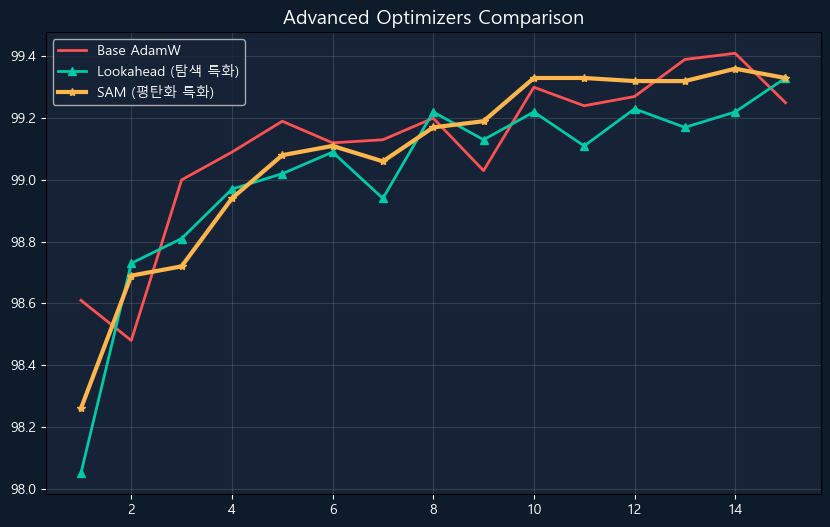


 [5 & 6번 과제 최종 결과 요약(MNIST, epoche=15)] 
-------------------------------------------------------
📍 Base AdamW 정확도 : 99.25%
📍 Lookahead 정확도  : 99.33% (가중치 진동 최소화 방어막)
📍 SAM 정확도        : 99.33% (Loss 표면 깎아내기 효과 발동!)


In [31]:
# 심화
# 5. **Lookahead Optimizer**를 직접 구현하거나 `torchcontrib`을 사용하여
#   AdamW와 비교해보세요.
# 6. **SAM (Sharpness-Aware Minimization)** 옵티마이저의 아이디어를 조사하고,
#   간단한 버전을 직접 구현하여 MNIST에 적용해보세요.
from collections import defaultdict

# ─── 5 & 6. 고급 옵티마이저 구현 (Lookahead & SAM) ─────────────────
# [과제 5] Lookahead Optimizer 구현 - 두개의 가중치로 더 나은 길 탐색
class Lookahead(optim.Optimizer):
    def __init__(self, optimizer, k=5, alpha=0.5):
        self.optimizer = optimizer
        self.k = k
        self.alpha = alpha
        self.param_groups = self.optimizer.param_groups
        self.state = defaultdict(dict)
        # 느린 가중치(Slow weights) 초기화
        for group in self.param_groups:
            for p in group['params']:
                self.state[p]['slow_param'] = p.clone().detach()
        self.step_counter = 0

    def step(self, closure=None):
        loss = self.optimizer.step(closure)
        self.step_counter += 1
        # k번마다 빠른 가중치와 느린 가중치의 위치를 섞어줌 (알파 비율만큼)
        if self.step_counter % self.k == 0:
            for group in self.param_groups:
                for p in group['params']:
                    if p.grad is None: continue
                    slow = self.state[p]['slow_param']
                    slow.add_(p.data - slow, alpha=self.alpha)
                    p.data.copy_(slow)
        return loss

    def zero_grad(self):
        self.optimizer.zero_grad()

# [과제 6] SAM (Sharpness-Aware Minimization) 구현
class SAM(torch.optim.Optimizer):
    def __init__(self, params, base_optimizer, rho=0.05, **kwargs):
        defaults = dict(rho=rho, **kwargs)
        super(SAM, self).__init__(params, defaults)
        self.base_optimizer = base_optimizer(self.param_groups, **kwargs)
        self.param_groups = self.base_optimizer.param_groups
    
    @torch.no_grad()
    def first_step(self, zero_grad=False):
        # 1) 그래디언트 측정 및 Local Maxima로 이동
        grad_norm = torch.norm(torch.stack([p.grad.norm(p=2) for group in self.param_groups for p in group["params"] if p.grad is not None]), p=2)
        for group in self.param_groups:
            scale = group["rho"] / (grad_norm + 1e-12)
            for p in group["params"]:
                if p.grad is None: continue
                self.state[p]["e_w"] = p.grad * scale.to(p)
                p.add_(self.state[p]["e_w"]) 
        if zero_grad: self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        # 2) Local Maxima를 기준으로 측정한 안전한 방향으로 이동
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None: continue
                p.sub_(self.state[p]["e_w"]) 
        self.base_optimizer.step() 
        if zero_grad: self.zero_grad()

# ─── 실험 진행 루프 ───────────────────────────────────────────────────────
print("\n" + "="*55)
print("=== 5&6. 고급 최적화 기법 한계돌파 테스트 (MNIST, epoche=15) ===")
print("="*55)
epochs_adv = 15
histories_adv = {}

# 테스트할 기법 라인업
opt_configs = {
    '1_AdamW': 'adamw',
    '2_Lookahead_AdamW': 'lookahead',
    '3_SAM_AdamW': 'sam'
}
for name, mode in opt_configs.items():
    print(f"\n🧪 [{name}] 모델 훈련 시작)")
    model = MnistCNN(dropout=0.5).to(device)
    criterion = nn.CrossEntropyLoss()
    
    # 모드에 따른 옵티마이저 생성
    if mode == 'adamw':
        optimizer = optim.AdamW(model.parameters(), lr=0.001)

    elif mode == 'lookahead':
        base_opt = optim.AdamW(model.parameters(), lr=0.001)
        optimizer = Lookahead(base_opt, k=5, alpha=0.5)

    elif mode == 'sam':
        optimizer = SAM(model.parameters(), optim.AdamW, lr=0.001, rho=0.05)
    
    test_acc_list = []

    for ep in range(1, epochs_adv + 1):
        model.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            if mode == 'sam':
                # SAM은 등산을 두 번 함 : 첫 번째 스텝
                out = model(imgs)
                loss = criterion(out, labels)
                loss.backward()
                optimizer.first_step(zero_grad=True)
                # 두 번째 스텝
                criterion(model(imgs), labels).backward()
                optimizer.second_step(zero_grad=True)

            else:
                # 일반 & Lookahead 스텝
                optimizer.zero_grad()
                out = model(imgs)
                criterion(out, labels).backward()
                optimizer.step()
                
        # 에폭 끝날 때마다 평가
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for imgs, labels in test_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                correct += (model(imgs).argmax(1) == labels).sum().item()
                total += imgs.size(0)
        
        ep_acc = correct / total * 100
        test_acc_list.append(ep_acc)
        print(f"  ⏳ {ep:>2}/{epochs_adv} 완료... (Acc: {ep_acc:.2f}%)", end='\r')
        
    print(f"  ✅ [완료] 최종 Test Acc: {test_acc_list[-1]:.2f}%              ")
    histories_adv[name] = test_acc_list
    
# ─── 시각화 및 결과 요약 ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0d1b2a')
ax.set_facecolor('#162236')
ax.tick_params(colors='white')
ax.plot(range(1, epochs_adv+1), histories_adv['1_AdamW'], color='#ff5252', lw=2, label='Base AdamW')
ax.plot(range(1, epochs_adv+1), histories_adv['2_Lookahead_AdamW'], color='#00c9a7', lw=2, marker='^', label='Lookahead (탐색 특화)')
ax.plot(range(1, epochs_adv+1), histories_adv['3_SAM_AdamW'], color='#ffb74d', lw=3, marker='*', label='SAM (평탄화 특화)')
ax.set_title('Advanced Optimizers Comparison', color='white', fontsize=14)
ax.legend(facecolor='#162236', labelcolor='white')
ax.grid(alpha=0.2)
plt.show()

print("\n" + "="*55)
print(" [5 & 6번 과제 최종 결과 요약(MNIST, epoche=15)] ")
print("-" * 55)
print(f"📍 Base AdamW 정확도 : {histories_adv['1_AdamW'][-1]:.2f}%")
print(f"📍 Lookahead 정확도  : {histories_adv['2_Lookahead_AdamW'][-1]:.2f}% (가중치 진동 최소화 방어막)")
print(f"📍 SAM 정확도        : {histories_adv['3_SAM_AdamW'][-1]:.2f}% (Loss 표면 깎아내기 효과 발동!)")
print("="*55)



=== 7. 7-Segment MLP(5층) 기울기 소실 방어 실험(활성화함수 Sigmoid) ===

🧪 [No_BN] 모델 훈련 시작...
  ✅ [완료] 최종 Test Acc: 44.67%      

🧪 [With_BN] 모델 훈련 시작...
  ✅ [완료] 최종 Test Acc: 65.33%      


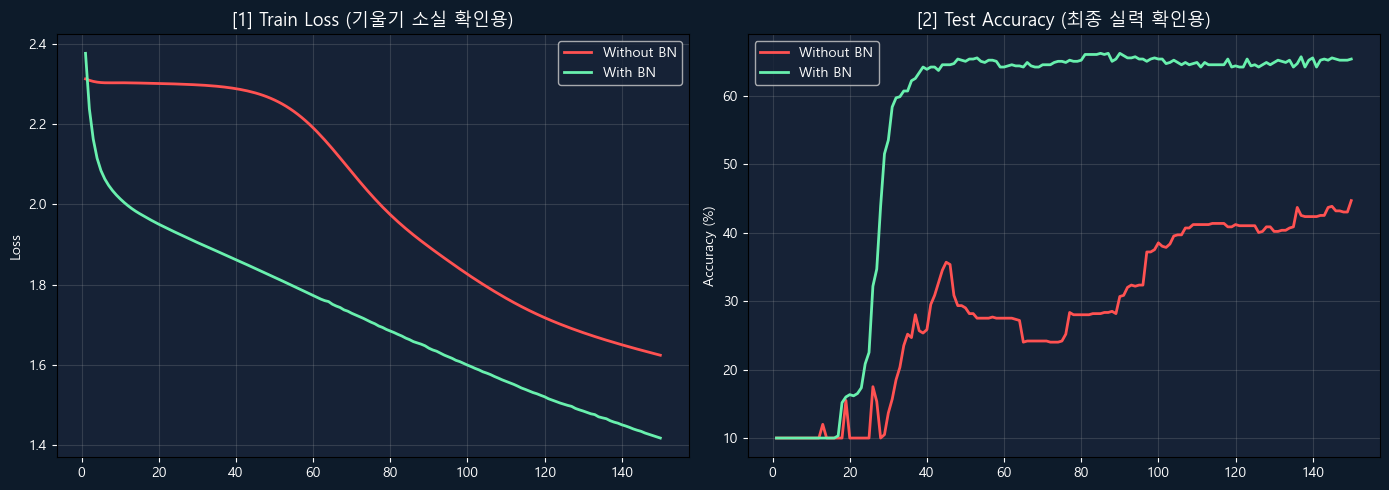


 [ 7-Segment MLP(5층) 기울기 소실 방어 실험 최종 결과(활성화함수 Sigmoid) ] 
----------------------------------------------------------------------
📍 BatchNorm 미적용 : Loss 1.625 / Acc 44.67%
📍 BatchNorm 적용됨 : Loss 1.418 / Acc 65.33%


In [30]:
# 심화
# 7. 7-Segment MLP를 5층 깊은 네트워크(7→256→128→64→32→10)로 바꾸면
#   Vanishing Gradient가 발생하는지 확인하고, BatchNorm을 추가하면 어떻게 되나요?

# ─── 7. 깊은 네트워크(5층)와 기울기 소실 방어 실험 (7-Segment) ──────────────

# BN(BatchNorm)이 없는 순수 5층 네트워크
class DeepSevenSeg_NoBN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(7, 256), nn.Sigmoid(),
            nn.Linear(256, 128), nn.Sigmoid(),
            nn.Linear(128, 64), nn.Sigmoid(),
            nn.Linear(64, 32), nn.Sigmoid(),
            nn.Linear(32, 10) # 출력 10개
        )
    def forward(self, x): return self.net(x)

# BN(BatchNorm)을 층마다 배치한 5층 네트워크
class DeepSevenSeg_WithBN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(7, 256), nn.BatchNorm1d(256), nn.Sigmoid(),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.Sigmoid(),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.Sigmoid(),
            nn.Linear(64, 32), nn.BatchNorm1d(32), nn.Sigmoid(),
            nn.Linear(32, 10)
        )
    def forward(self, x): return self.net(x)

# ─── 실험 진행 루프 ───────────────────────────────────────────────────────
print("\n" + "="*70)
print("=== 7. 7-Segment MLP(5층) 기울기 소실 방어 실험(활성화함수 Sigmoid) ===")
print("="*70)

Xtr, ytr, Xte, yte = make_seg_data(noise_prob=0.15, samples=300)

epochs_deep = 150

# 'loss'와 'acc'를 모두 기록
histories_deep = {
    'No_BN': {'loss': [], 'acc': []}, 
    'With_BN': {'loss': [], 'acc': []}
}

for mode in ['No_BN', 'With_BN']:
    print(f"\n🧪 [{mode}] 모델 훈련 시작...")
    model = DeepSevenSeg_WithBN().to(device) if mode == 'With_BN' else DeepSevenSeg_NoBN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    for ep in range(1, epochs_deep + 1):
        model.train()
        optimizer.zero_grad()
        out = model(Xtr)
        loss = criterion(out, ytr)
        loss.backward()
        optimizer.step()
        
        # Train Loss 기록
        histories_deep[mode]['loss'].append(loss.item())
        
        # Test Acc 평가 기록
        model.eval()
        with torch.no_grad():
            correct = (model(Xte).argmax(1) == yte).sum().item()
            acc = correct / len(yte) * 100
            histories_deep[mode]['acc'].append(acc)
            
        print(f"  ⏳ {ep:>3}/{epochs_deep} 에폭 완료...", end='\r')
    print(f"  ✅ [완료] 최종 Test Acc: {histories_deep[mode]['acc'][-1]:.2f}%      ")

# ─── 시각화 (2개의 그래프 나란히 배치) ───────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d1b2a')
for ax in (ax1, ax2):
    ax.set_facecolor('#162236')
    ax.tick_params(colors='white')
    ax.grid(alpha=0.2)

# [왼쪽] Train Loss (낮을수록 좋음 - 모델의 학습 의지)
ax1.plot(range(1, epochs_deep+1), histories_deep['No_BN']['loss'], color='#ff5252', lw=2, label='Without BN')
ax1.plot(range(1, epochs_deep+1), histories_deep['With_BN']['loss'], color='#69f0ae', lw=2, label='With BN')
ax1.set_title('[1] Train Loss (기울기 소실 확인용)', color='white', fontsize=13)
ax1.set_ylabel('Loss', color='white')
ax1.legend(facecolor='#162236', labelcolor='white')

# [오른쪽] Test Accuracy (높을수록 좋음 - 실력)
ax2.plot(range(1, epochs_deep+1), histories_deep['No_BN']['acc'], color='#ff5252', lw=2, label='Without BN')
ax2.plot(range(1, epochs_deep+1), histories_deep['With_BN']['acc'], color='#69f0ae', lw=2, label='With BN')
ax2.set_title('[2] Test Accuracy (최종 실력 확인용)', color='white', fontsize=13)
ax2.set_ylabel('Accuracy (%)', color='white')
ax2.legend(facecolor='#162236', labelcolor='white')
plt.tight_layout()
plt.show()

# ─── 최종 결과 요약 ────────────────────────────────────────────────────────────
print("\n" + "="*70)
print(" [ 7-Segment MLP(5층) 기울기 소실 방어 실험 최종 결과(활성화함수 Sigmoid) ] ")
print("-" * 70)
print(f"📍 BatchNorm 미적용 : Loss {histories_deep['No_BN']['loss'][-1]:.3f} / Acc {histories_deep['No_BN']['acc'][-1]:.2f}%")
print(f"📍 BatchNorm 적용됨 : Loss {histories_deep['With_BN']['loss'][-1]:.3f} / Acc {histories_deep['With_BN']['acc'][-1]:.2f}%")
print("=" * 70)
